데이터 처리 

In [3]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-r", r"C:\Users\Administrator\OneDrive\Documents\GitHub\Bank_Detection_project\requirements.txt","sam","ultralytics"])


CompletedProcess(args=['c:\\Users\\Administrator\\miniconda3\\envs\\myenv\\python.exe', '-m', 'pip', 'install', '-r', 'C:\\Users\\Administrator\\OneDrive\\Documents\\GitHub\\Bank_Detection_project\\requirements.txt', 'sam', 'ultralytics'], returncode=0)

In [4]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


In [5]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_0ec455321635f78f76c0ff1aae1c2eb4'

import kagglehub
path = kagglehub.competition_download('ai12-level1-project')
print("Path to competition files:", path)


c:\Users\Administrator\miniconda3\envs\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to competition files: C:\Users\Administrator\.cache\kagglehub\competitions\ai12-level1-project


In [6]:
import glob
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import Counter, defaultdict
from PIL import Image


In [7]:
data_path = r'C:\Users\Administrator\.cache\kagglehub\competitions\ai12-level1-project'
label_files = glob.glob(data_path + '/**/*.json', recursive=True)
print(f"라벨 파일 수: {len(label_files)}")

merged = defaultdict(list)
image_info = {}
total_cat_dict = {}

for f in label_files:
    with open(f, 'r', encoding='utf-8') as file:
        data = json.load(file)
    img = data['images'][0]
    file_name = img.get('file_name')
    if file_name not in image_info:
        image_info[file_name] = img
    for cat in data.get('categories', []):
        total_cat_dict[cat['id']] = cat['name']
    for ann in data.get('annotations', []):
        if len(ann.get('bbox', [])) == 4:
            merged[file_name].append(ann)

print(f"고유 이미지 수: {len(merged)}")
print(f"클래스 수: {len(total_cat_dict)}")
first_key = list(merged.keys())[0]
print(f"첫 번째 이미지 bbox 수: {len(merged[first_key])}")


라벨 파일 수: 763
고유 이미지 수: 232
클래스 수: 56
첫 번째 이미지 bbox 수: 4


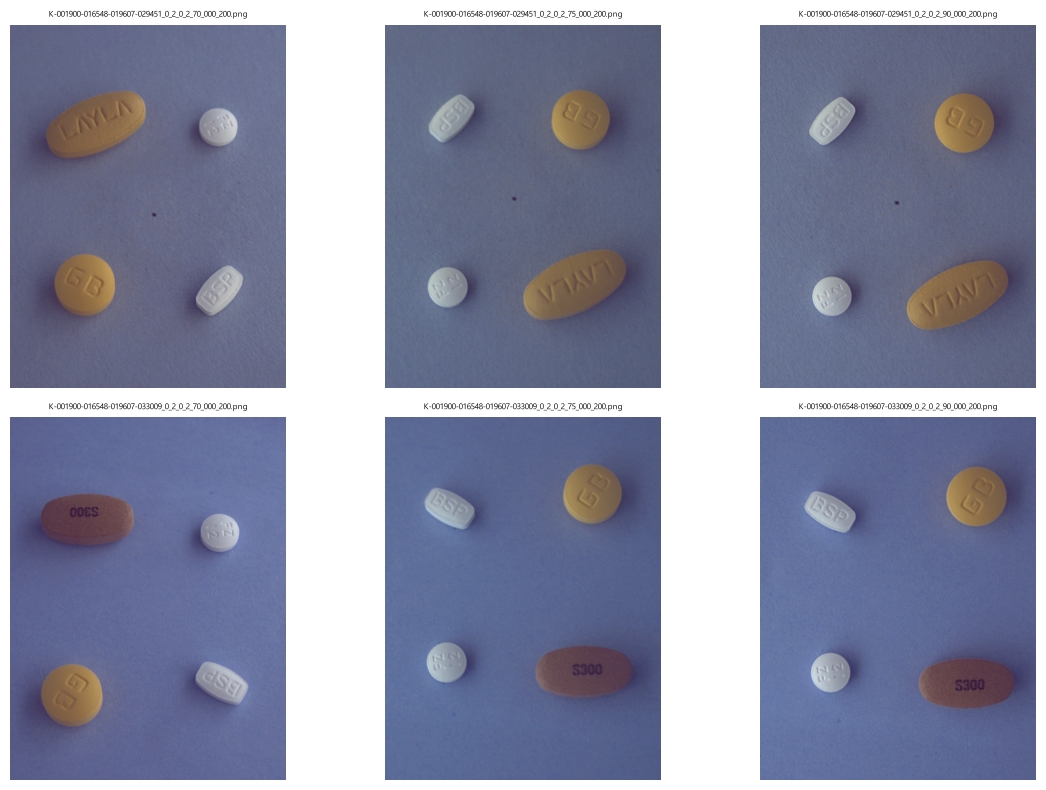

In [8]:
# 이미지 샘플 6개 시각화
sample_files = list(merged.keys())[:6]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, file_name in zip(axes.flatten(), sample_files):
    for root, dirs, files in os.walk(data_path):
        if file_name in files:
            img = Image.open(os.path.join(root, file_name))
            ax.imshow(img)
            ax.set_title(file_name, fontsize=6)
            ax.axis('off')
            break
plt.tight_layout()
plt.show()


In [9]:
with open(label_files[0], 'r', encoding='utf-8') as f:
    data = json.load(f)

print(f"images 수: {len(data.get('images', []))}")
print(f"annotations 수: {len(data.get('annotations', []))}")
print(f"categories 수: {len(data.get('categories', []))}")

print("\n=== categories 전체 ===")
for cat in data.get('categories', []):
    print(cat)

print("\n=== annotations 첫 번째 ===")
print(json.dumps(data['annotations'][0], indent=2, ensure_ascii=False))


images 수: 1
annotations 수: 1
categories 수: 1

=== categories 전체 ===
{'supercategory': 'pill', 'id': 1900, 'name': '보령부스파정 5mg'}

=== annotations 첫 번째 ===
{
  "area": 35910,
  "iscrowd": 0,
  "bbox": [
    644,
    845,
    189,
    190
  ],
  "category_id": 1900,
  "ignore": 0,
  "segmentation": [],
  "id": 133,
  "image_id": 34
}


총 이미지 수: 763
약품의 종류 수: 56
알약의 모양 대표 5
원형: 329개
타원형: 261개
장방형: 146개
None: 18개
팔각형: 6개


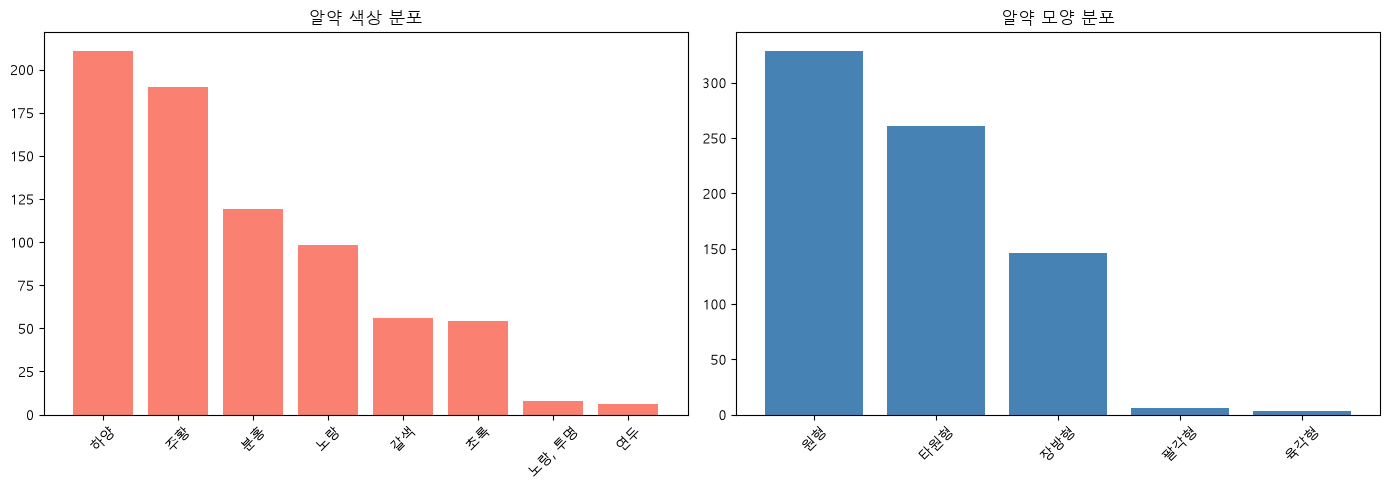

In [10]:
drug_names = []
shapes = []
colors = []
bbox_areas = []

for f in label_files:
    with open(f, 'r', encoding='utf-8') as file:
        data = json.load(file)
    for img in data.get('images', []):
        drug_names.append(img.get('dl_name', ''))
        shapes.append(img.get('drug_shape', ''))
        colors.append(img.get('color_class1', ''))
    for ann in data.get('annotations', []):
        bbox = ann.get('bbox', [])
        if bbox:
            bbox_areas.append(bbox[2] * bbox[3])

print(f"총 이미지 수: {len(drug_names)}")
print(f"약품의 종류 수: {len(set(drug_names))}")
print("알약의 모양 대표 5")
for shape, cnt in Counter(shapes).most_common(5):
    print(f"{shape}: {cnt}개")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_filtered = [c for c in colors if c is not None]
color_counter = Counter(colors_filtered).most_common(8)
axes[0].bar([x[0] for x in color_counter], [x[1] for x in color_counter], color='salmon')
axes[0].set_title('알약 색상 분포')
axes[0].tick_params(axis='x', rotation=45)

shape_filtered = [c for c in shapes if c is not None]
shape_counter = Counter(shape_filtered).most_common(8)
axes[1].bar([x[0] for x in shape_counter], [x[1] for x in shape_counter], color='steelblue')
axes[1].set_title('알약 모양 분포')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [11]:
file_name_counter = Counter()
for f in label_files:
    with open(f, 'r', encoding='utf-8') as file:
        data = json.load(file)
    for img in data.get('images', []):
        file_name_counter[img.get('file_name')] += 1

print(f"고유 이미지 수: {len(file_name_counter)}")
print(f"JSON 당 평균 분산: {sum(file_name_counter.values()) / len(file_name_counter):.1f}개")
print(f"\n가장 많이 분산된 이미지 TOP 5:")
for fname, cnt in file_name_counter.most_common(5):
    print(f"  {fname}: {cnt}개 JSON")


고유 이미지 수: 232
JSON 당 평균 분산: 3.3개

가장 많이 분산된 이미지 TOP 5:
  K-001900-016548-019607-029451_0_2_0_2_70_000_200.png: 4개 JSON
  K-001900-016548-019607-029451_0_2_0_2_75_000_200.png: 4개 JSON
  K-001900-016548-019607-029451_0_2_0_2_90_000_200.png: 4개 JSON
  K-001900-016548-019607-033009_0_2_0_2_70_000_200.png: 4개 JSON
  K-001900-016548-019607-033009_0_2_0_2_75_000_200.png: 4개 JSON


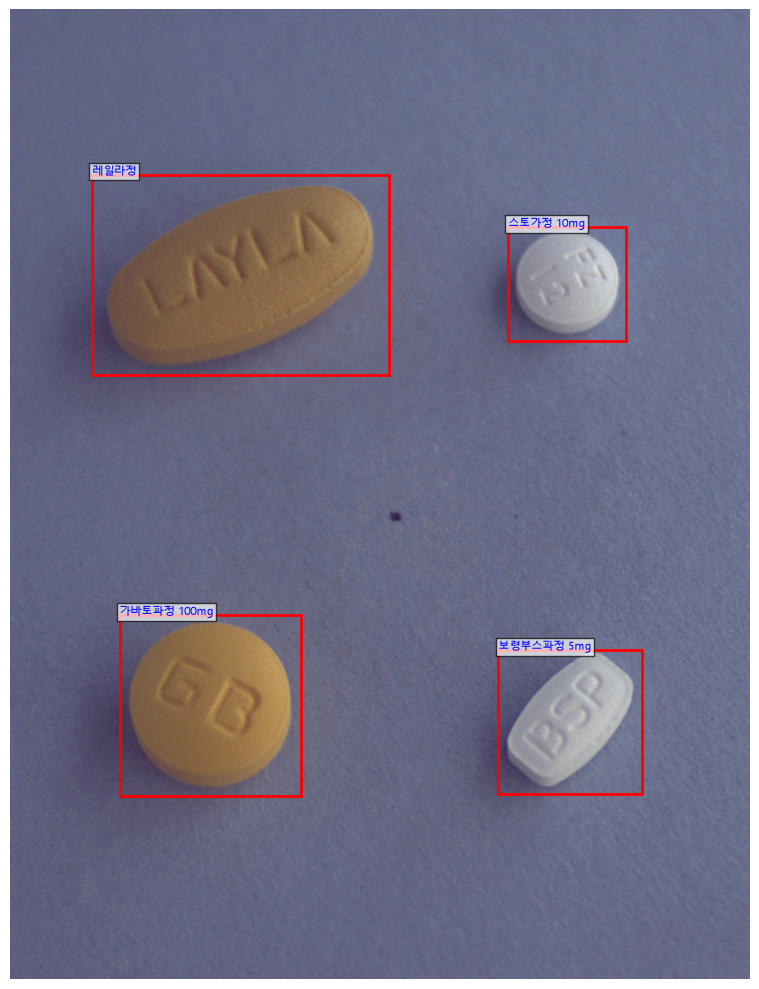

In [12]:
img_info = list(image_info.values())[0]
file_name = img_info['file_name']
annotations = merged[file_name]

img_files = []
for root, dirs, files in os.walk(data_path):
    if file_name in files:
        img_files.append(os.path.join(root, file_name))
        break

if img_files:
    img = Image.open(img_files[0])
    fig, ax = plt.subplots(1, figsize=(8, 10))
    ax.imshow(img)
    for ann in annotations:
        cat_name = total_cat_dict[ann['category_id']]
        x, y, w, h = ann['bbox']
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y, cat_name, fontsize=8, color='blue',
                bbox=dict(facecolor='white', alpha=0.7, pad=2))
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("이미지 파일을 못 찾았어요!")


In [13]:
aihub_path = r'C:\Users\Administrator\OneDrive\Documents\GitHub\Bank_Detection_project\data\166.약품식별_인공지능_개발을_위한_경구약제_이미지_데이터'

aihub_class_counter = Counter()
for root, dirs, files in os.walk(aihub_path):
    for file in files:
        if file.endswith('.json'):
            try:
                with open(os.path.join(root, file), 'r', encoding='utf-8') as f:
                    dl_name = json.load(f)['images'][0].get('dl_name', '')
                if dl_name:
                    aihub_class_counter[dl_name] += 1
            except:
                pass

print(f"AI Hub: {len(aihub_class_counter)}개 클래스, {sum(aihub_class_counter.values())}개 annotation")


AI Hub: 116개 클래스, 40413개 annotation


Kaggle 클래스 수: 56개
샘플 5개:
  idx 0: 보령부스파정 5mg / 성분: 부스피론염산염
  idx 1: 뮤테란캡슐 100mg / 성분: 아세틸시스테인
  idx 2: 일양하이트린정 2mg / 성분: 테라조신염산염수화물
  idx 3: 기넥신에프정(은행엽엑스)(수출용) / 성분: 은행엽건조엑스
  idx 4: 무코스타정(레바미피드)(비매품) / 성분: 레바미피드

AI Hub 매칭된 클래스: 54개
통합 클래스: 56개


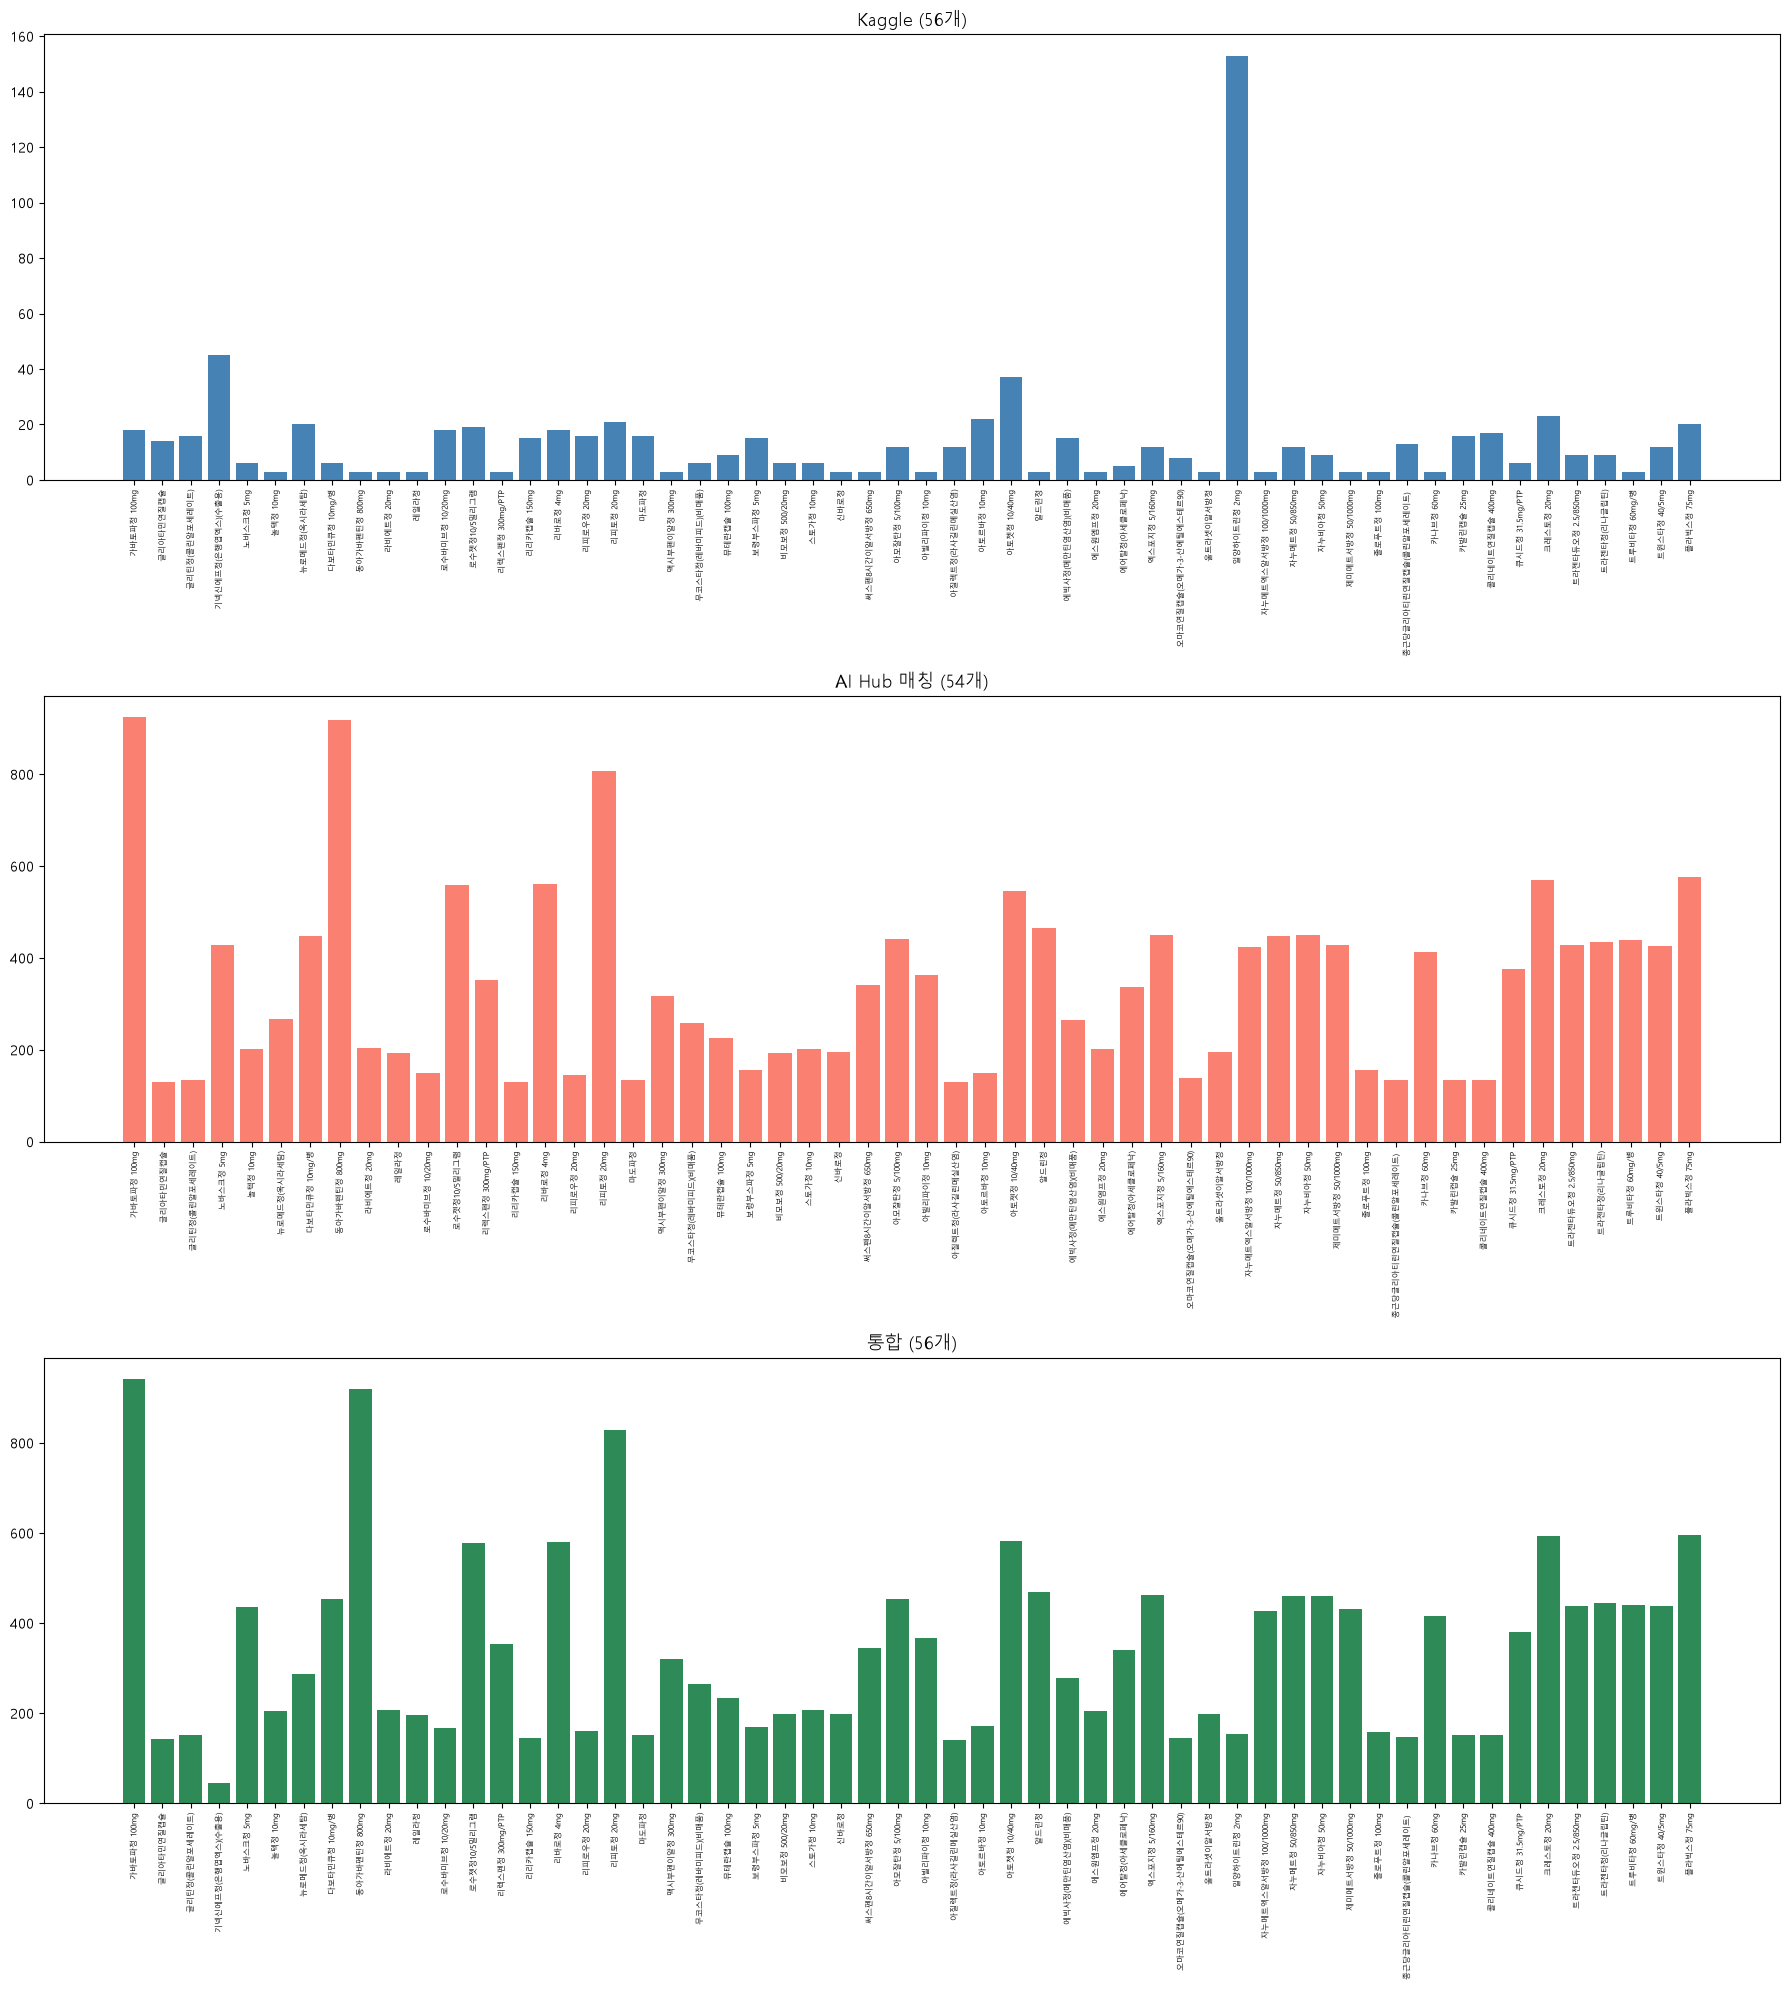


20개 미만 클래스:


In [14]:
# Kaggle category_id 기준 클래스맵
# category_id -> dl_name, dl_material 전부 저장
kaggle_cat_info = {}  # category_id -> {name, material}
for f in label_files:
    with open(f, 'r', encoding='utf-8') as file:
        data = json.load(file)
    img = data['images'][0]
    for cat in data.get('categories', []):
        cat_id = cat['id']
        if cat_id not in kaggle_cat_info:
            kaggle_cat_info[cat_id] = {
                'name': cat['name'],
                'material': img.get('dl_material', ''),
                'shape': img.get('drug_shape', ''),
                'color': img.get('color_class1', ''),
            }

# category_id 0~55 재매핑
sorted_cat_ids = sorted(kaggle_cat_info.keys())
cat_id_to_idx = {cat_id: idx for idx, cat_id in enumerate(sorted_cat_ids)}
idx_to_cat_info = {idx: kaggle_cat_info[cat_id] for cat_id, idx in cat_id_to_idx.items()}

print(f"Kaggle 클래스 수: {len(cat_id_to_idx)}개")
print("샘플 5개:")
for idx, info in list(idx_to_cat_info.items())[:5]:
    print(f"  idx {idx}: {info['name']} / 성분: {info['material']}")

# AI Hub dl_name -> Kaggle category_id 매핑
name_to_cat_id = {info['name']: cat_id for cat_id, info in kaggle_cat_info.items()}

# Kaggle 클래스 카운트
kaggle_class_counter = Counter()
for file_name, anns in merged.items():
    for ann in anns:
        name = total_cat_dict[ann['category_id']]
        kaggle_class_counter[name] += 1

# AI Hub 클래스 카운트 (Kaggle 클래스에 있는 것만)
aihub_matched_counter = Counter()
for name, cnt in aihub_class_counter.items():
    if name in name_to_cat_id:
        aihub_matched_counter[name] += cnt

merged_counter = kaggle_class_counter + aihub_matched_counter

print(f"\nAI Hub 매칭된 클래스: {len(aihub_matched_counter)}개")
print(f"통합 클래스: {len(merged_counter)}개")

# 그래프
fig, axes = plt.subplots(3, 1, figsize=(18, 20))

for ax, counter, title, color in [
    (axes[0], kaggle_class_counter, f'Kaggle ({len(kaggle_class_counter)}개)', 'steelblue'),
    (axes[1], aihub_matched_counter, f'AI Hub 매칭 ({len(aihub_matched_counter)}개)', 'salmon'),
    (axes[2], merged_counter,        f'통합 ({len(merged_counter)}개)', 'seagreen'),
]:
    keys = sorted(counter.keys())
    ax.bar(range(len(keys)), [counter[k] for k in keys], color=color)
    ax.set_title(title, fontsize=13)
    ax.set_xticks(range(len(keys)))
    ax.set_xticklabels(keys, rotation=90, fontsize=6)

plt.tight_layout()
plt.show()

print("\n20개 미만 클래스:")
for name, cnt in sorted(merged_counter.items(), key=lambda x: x[1]):
    if cnt < 20:
        print(f"  {name}: {cnt}개")


In [15]:
# 최종 클래스 정보 확인
print(f"최종 클래스 수: {len(idx_to_cat_info)}개")
print(f"{'idx':>4} | {'category_id':>12} | {'약품명':<40} | 성분")
print('-' * 100)
for cat_id, idx in sorted(cat_id_to_idx.items()):
    info = kaggle_cat_info[cat_id]
    print(f"  {idx:>2} | {cat_id:>12} | {info['name']:<40} | {info['material']}")


최종 클래스 수: 56개
 idx |  category_id | 약품명                                      | 성분
----------------------------------------------------------------------------------------------------
   0 |         1900 | 보령부스파정 5mg                               | 부스피론염산염
   1 |         2483 | 뮤테란캡슐 100mg                              | 아세틸시스테인
   2 |         3351 | 일양하이트린정 2mg                              | 테라조신염산염수화물
   3 |         3483 | 기넥신에프정(은행엽엑스)(수출용)                       | 은행엽건조엑스
   4 |         3544 | 무코스타정(레바미피드)(비매품)                        | 레바미피드
   5 |         3743 | 알드린정                                     | 알마게이트
   6 |         3832 | 뉴로메드정(옥시라세탐)                             | 옥시라세탐
   7 |         4543 | 에어탈정(아세클로페낙)                             | 아세클로페낙
   8 |        12081 | 리렉스펜정 300mg/PTP                          | 아세트아미노펜|클로르족사존
   9 |        12247 | 아빌리파이정 10mg                              | 아리피프라졸
  10 |        12778 | 다보타민큐정 10mg/병                            | 
  11 |        13395

In [29]:
import pandas as pd

# 마스터 테이블 생성 - Kaggle category_id 기준 전체 필드
master_table = []
for f in label_files:
    with open(f, 'r', encoding='utf-8') as file:
        data = json.load(file)
    img = data['images'][0]
    for cat in data.get('categories', []):
        cat_id = cat['id']
        if cat_id not in {row['category_id'] for row in master_table}:
            master_table.append({
                'idx': cat_id_to_idx[cat_id],
                'category_id': cat_id,
                'dl_name': cat['name'],
                'dl_name_en': img.get('dl_name_en', ''),
                'dl_material': img.get('dl_material', ''),
                'dl_company': img.get('dl_company', ''),
                'di_class_no': img.get('di_class_no', ''),
                'di_etc_otc_code': img.get('di_etc_otc_code', ''),
                'drug_shape': img.get('drug_shape', ''),
                'color': img.get('color_class1', ''),
                'print_front': img.get('print_front', ''),
                'print_back': img.get('print_back', ''),
                'leng_long': img.get('leng_long', ''),
                'leng_short': img.get('leng_short', ''),
                'thick': img.get('thick', ''),
                'line_front': img.get('line_front', ''),
                'line_back': img.get('line_back', ''),
                'kaggle_count': kaggle_class_counter.get(cat['name'], 0),
                'aihub_count': aihub_matched_counter.get(cat['name'], 0),
                'total_count': merged_counter.get(cat['name'], 0),
            })

master_df = pd.DataFrame(master_table).sort_values('idx').reset_index(drop=True)

# 20개 미만 확인
under_20 = master_df[master_df['total_count'] < 20]
if len(under_20) > 0:
    print(f"20개 미만 클래스: {len(under_20)}개")
    print(under_20[['idx', 'dl_name', 'total_count']].to_string(index=False))
else:
    print("모든 클래스 20개 이상 OK")

print(f"\n마스터 테이블: {len(master_df)}개 클래스, {len(master_df.columns)}개 컬럼")
print(master_df.to_string(index=False))

# CSV 저장
save_path = r'C:\Users\Administrator\OneDrive\Documents\GitHub\Bank_Detection_project\data\class_master_table.csv'
master_df.to_csv(save_path, index=False, encoding='utf-8-sig')
print(f"\nCSV 저장 완료: {save_path}")


모든 클래스 20개 이상 OK

마스터 테이블: 56개 클래스, 20개 컬럼
 idx  category_id                  dl_name                       dl_name_en                                     dl_material   dl_company                   di_class_no di_etc_otc_code drug_shape  color         print_front      print_back  leng_long  leng_short  thick line_front line_back  kaggle_count  aihub_count  total_count
   0         1900               보령부스파정 5mg          Buspar Tab. 5mg Boryung                                         부스피론염산염      보령제약(주)                 [01170]정신신경용제           전문의약품        장방형     하양                 BSP               5       8.00        4.50   2.50                                 15          155          170
   1         2483              뮤테란캡슐 100mg               Muteran Cap. 100mg                                         아세틸시스테인      한화제약(주)                  [02220]진해거담제           일반의약품        장방형     초록       Hanwha MUC100                      19.00        6.40   6.80                                  9